In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Netflix_Project/mymoviedb.csv",
    engine="python"
)

# Initial Data Inspection
# Purpose: Understand dataset structure and contents

In [4]:
# Display first 10 records
df.head(10)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
5,2022-01-07,The Commando,An elite DEA agent returns home after a failed...,1750.484,33,6.6,en,"Action, Crime, Thriller",https://image.tmdb.org/t/p/original/pSh8MyYu5C...
6,2022-01-12,Scream,Twenty-five years after a streak of brutal mur...,1675.161,821,6.8,en,"Horror, Mystery, Thriller",https://image.tmdb.org/t/p/original/kZNHR1upJK...
7,2022-02-10,Kimi,A tech worker with agoraphobia discovers recor...,1601.782,206,6.3,en,Thriller,https://image.tmdb.org/t/p/original/okNgwtxIWz...
8,2022-02-17,Fistful of Vengeance,A revenge mission becomes a fight to save the ...,1594.013,114,5.3,en,"Action, Crime, Fantasy",https://image.tmdb.org/t/p/original/3cccEF9QZg...
9,2021-11-03,Eternals,The Eternals are a team of ancient aliens who ...,1537.406,4726,7.2,en,Science Fiction,https://image.tmdb.org/t/p/original/zByhtBvX99...


In [5]:
# Check dataset dimensions (rows, columns)
df.shape

(9837, 9)

In [6]:
# View column names
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [7]:
# Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


# Data Quality Assessment
# Purpose: Identify data issues before analysis

In [8]:
# Check missing values
# df.isnull().sum()

In [9]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [10]:
# Generate summary statistics
df.describe()


,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [11]:
#drop all null values
df = df.dropna()

In [12]:
df.isnull().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


# Data Type Conversion

In [13]:
# Convert Release_Date to datetime format
df["Release_Date"] =pd.to_datetime(df["Release_Date"])

In [14]:
print(df['Release_Date'].dtype)

datetime64[ns]


In [15]:
# Convert Vote_Count to numeric
df["Vote_Count"] = pd.to_numeric(df["Vote_Count"])

In [16]:
# Convert Vote_Average to numeric
df["Vote_Average"] = pd.to_numeric(df["Vote_Average"])

In [17]:
print(df[['Vote_Count','Vote_Average']].dtypes)

Vote_Count        int64
Vote_Average    float64
dtype: object


In [18]:
# Missing values after datatype conversion
df.isnull().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


# EDA (Exploratory Data Analysis)

In [19]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average
count,9826,9826.000000,9826.000000,9826.000000
mean,2006-09-23 04:47:14.276409600,40.323951,1392.943721,6.439467
min,1902-04-17 00:00:00,13.354000,0.000000,0.000000
25%,2000-10-17 12:00:00,16.128250,146.000000,5.900000
50%,2011-09-12 00:00:00,21.195000,444.000000,6.500000
75%,2017-11-22 00:00:00,35.179250,1376.000000,7.100000
max,2024-07-03 00:00:00,5083.954000,31077.000000,10.000000
std,NaN,108.879332,2611.303856,1.129797


In [20]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [21]:
# Create Year column for analysis
df["Year"] = df["Release_Date"].dt.year

In [22]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021
...,...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...,1973
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...,2020
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,2016
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,2021


In [23]:
# Movies per year
df["Year"].value_counts(ascending=False)

,count
Year,
2021,714
2018,530
2017,510
2019,500
2016,470
...,...
1925,1
1902,1
1920,1


In [24]:
# Top 10 Movies
df.nlargest(10, "Popularity")[["Title","Popularity"]]

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
1,The Batman,3827.658
2,No Exit,2618.087
3,Encanto,2402.201
4,The King's Man,1895.511
5,The Commando,1750.484
6,Scream,1675.161
7,Kimi,1601.782
8,Fistful of Vengeance,1594.013
9,Eternals,1537.406


In [25]:
# rating analysis
df.nlargest(10, "Vote_Average")[["Title","Vote_Average"]]

,Title,Vote_Average
9401,Kung Fu Master Huo Yuanjia,10.0
7349,Franco Escamilla: Por La Anécdota,9.2
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1
2335,Impossible Things,9.1
2401,The Three Deaths of Marisela Escobedo,9.0
6738,Mission «Sky»,9.0
7024,Sex School: Dorms of Desire,9.0
7411,My Sex Doll,9.0
5079,"Ni tuyo, Ni mía",8.9
7049,Bring the Soul: The Movie,8.9


# Categorizing vote_average column
#### we would cut the vote_average values make 4 categories: popular, average, below_avg,not_popular to describe it more using categorize_col() function provided above

In [26]:
def categorize_col(df, col, labels):

    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]

    df[col] = pd.cut(df[col], bins=edges, labels=labels, duplicates ='drop')
    return df

In [27]:
labels =['not_popular', 'below_avg','average','popular']

categorize_col(df,'Vote_Average',labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [28]:
df.head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,below_avg,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,popular,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,average,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021


In [29]:
df["Vote_Average"].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2411
below_avg,2398


In [30]:
df.dropna(inplace=True)
df.isna().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0
Year,0


## we'd split genre into a list and the explore our dataframe to have only pne genre per row for ezch movie

In [31]:
df["Genre"] =df["Genre"].str.split(', ')

df = df.explode("Genre").reset_index(drop=True)
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Action,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
1,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Adventure,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
2,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Science Fiction,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
3,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Crime,https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022
4,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Mystery,https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022


In [32]:
df.shape

(25551, 10)

# Casting column into category

In [33]:
df["Genre"] =df["Genre"].astype("category")

df["Genre"].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       25551 non-null  datetime64[ns]
 1   Title              25551 non-null  object        
 2   Overview           25551 non-null  object        
 3   Popularity         25551 non-null  float64       
 4   Vote_Count         25551 non-null  int64         
 5   Vote_Average       25551 non-null  category      
 6   Original_Language  25551 non-null  object        
 7   Genre              25551 non-null  category      
 8   Poster_Url         25551 non-null  object        
 9   Year               25551 non-null  int32         
dtypes: category(2), datetime64[ns](1), float64(1), int32(1), int64(1), object(4)
memory usage: 1.5+ MB


In [35]:
df.nunique()

,0
Release_Date,5845
Title,9414
Overview,9721
Popularity,8087
Vote_Count,3265
Vote_Average,4
Original_Language,42
Genre,19
Poster_Url,9726
Year,100


In [36]:
df = df.drop(["Overview","Poster_Url"], axis =1)

# Data Visualization

In [37]:
sns.set_style('whitegrid')

# what is the most frequent genre of movies released on netflix

In [38]:
df["Genre"].describe()

,Genre
count,25551
unique,19
top,Drama
freq,3715


In [39]:
df.shape

(25551, 8)

Text(0.5, 1.0, 'Genre column distribution')

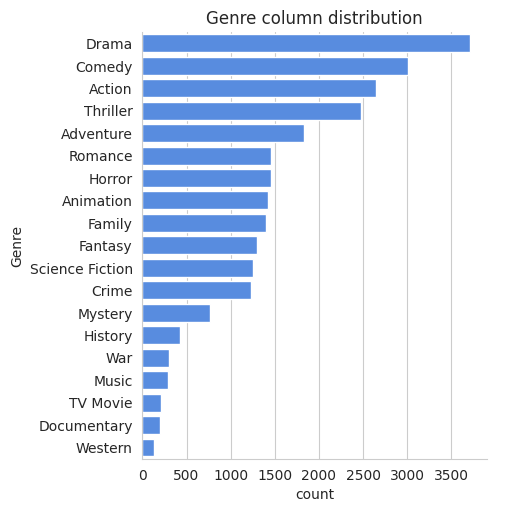

In [40]:
sns.catplot(y ='Genre' , data =df, kind ='count',
            order=df["Genre"].value_counts().index,
            color ='#4287f5')
plt.title("Genre column distribution")

# which has the highest votes in  avg column

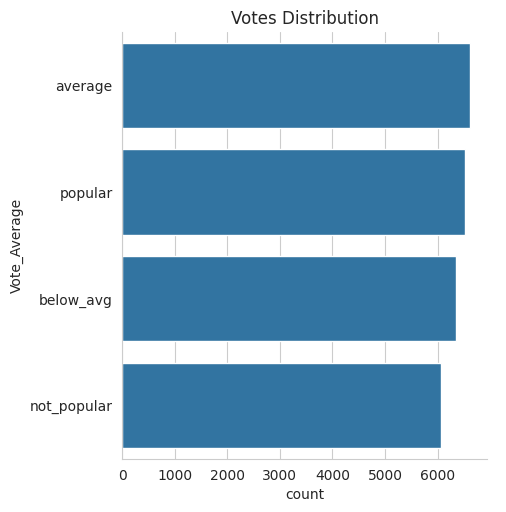

In [41]:
sns.catplot(y ='Vote_Average', data = df, kind ='count',
            order = df["Vote_Average"].value_counts().index,
            )
plt.title('Votes Distribution')
plt.show()

# What movie got the highest popularity? what its genre?


In [42]:
df[df["Popularity"] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,en,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,en,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,en,Science Fiction,2021


# What movie got the minimum popularity? what its genre?

In [43]:
df[df["Popularity"] == df["Popularity"].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Year
25545,2021-03-31,The United States vs. Billie Holiday,13.354,152,average,en,Music,2021
25546,2021-03-31,The United States vs. Billie Holiday,13.354,152,average,en,Drama,2021
25547,2021-03-31,The United States vs. Billie Holiday,13.354,152,average,en,History,2021
25548,1984-09-23,Threads,13.354,186,popular,en,War,1984
25549,1984-09-23,Threads,13.354,186,popular,en,Drama,1984
25550,1984-09-23,Threads,13.354,186,popular,en,Science Fiction,1984


# Which year has the most filmed movies

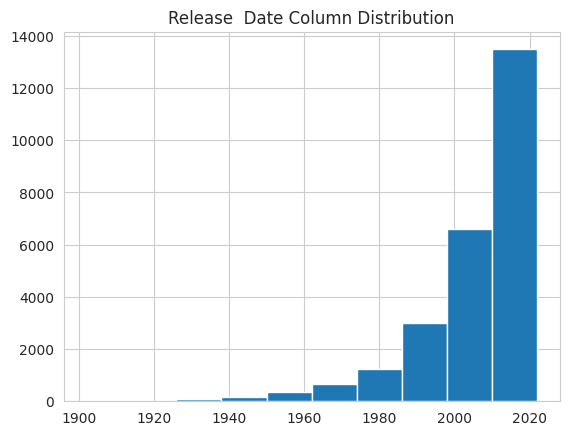

In [44]:
df['Year'].hist()
plt.title("Release  Date Column Distribution")
plt.show()

# Seummary


## Q1: What is the most frequent genre in the dataset?
Drama genre is the most frequent genre in our dataset and has appeared more than 14% of the times among 19 other genres.
## Q2: What genres has highest votes ?
we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the highest popularity among fans by being having more than 18.5% of movies popularities.
## Q3: What movie got the highest popularity? what's its genre?
Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action, Adventure and Sience Fiction.
## Q4: What movie got the lowest popularity? what's its genre?
The united states, thread' has the highest lowest rate in our dataset and it has genres of music, drama, 'war', 'sci-fi' and history`.
## Q5: Which year has the most filmmed movies?
year 2020 has the highest filmming rate in our dataset.